<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
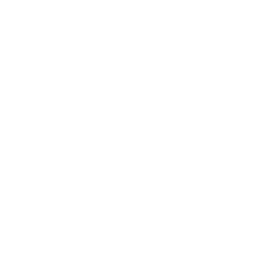
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">제철소 압연 공정 모니터링</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 열간 압연 스트립 밀 두께 및 표면 품질관리를 위한 다변량 SPC &nbsp;|&nbsp; 2026년 3월</p>
</div>
</div>
</div>

## 요약

열간 압연 스트립 밀은 강판 슬래브를 얇은 코일로 압연한다. 서로 상관된 6가지 공정 신호(두께 2종, 압연력, 롤 간극, 모터 전류, 출측 온도)는 라인이 정상일 때 함께 움직이므로, 이를 한 번에 하나씩 차트로 모니터링하면 정작 중요한 결합된 변화를 놓치게 된다. 이 예제는 **PROC MVPMODEL**로 다변량 기준 모형을 구축한 뒤, 생산 코일 100개를 **PROC MVPMONITOR**에 통과시켜 각 코일에 단일 Hotelling *T*&sup2; 통계량으로 점수를 매기고 관리한계와 비교한다.

관리상태 한계 *T*&sup2; = **17.13** (&alpha; = 0.05) 기준으로, **100개 코일 중 4개**가 관리이탈 신호를 보인다 — 코일 **91, 92, 94, 95**로, 백업롤 채터링 돌발이 주입된 구간과 정확히 일치한다. 최고 *T*&sup2;는 코일 95에서 **21.91**에 도달하며, 이는 한계값의 약 **1.3&times;**이다. 후반 코일에 걸친 점진적인 롤 마모 램프는 기준 *T*&sup2;를 끌어올리지만 채터링 사건 전까지는 한계 아래에 머무르므로, 이 차트는 즉각적인 조치가 필요한 급성 결함과 완만한 드리프트를 명확히 구분해 낸다.

## 데이터 출처

- **mill_baseline** &mdash; 캠페인 중 상태가 양호했던 구간에서 압연된 코일 50개; 다변량(PCA) 기준 모형을 적합하는 데 사용.
- **mill_stream** &mdash; 실제 라인에서 나온 코일 100개. 코일 1&ndash;55는 관리상태에서 가동되고, 롤 마모는 코일 56&ndash;100에 걸쳐 점진적으로 진행되며, 백업롤 채터링 돌발이 코일 91&ndash;95를 강타한다.
- **공정 변수** (6개): `entry_thickness`, `exit_thickness`,
  `rolling_force`, `roll_gap`, `motor_current`, `exit_temp`.

> 이 환경은 라이선스 없이 실행되므로 데이터셋은 100개 관측치로 제한된다. 시나리오는 이 한도에 맞춰 설계되었다: 이상 신호가 5,000개 중 2,800번째 코일이 아니라 100개 코일 스트림의 후반부에 배치되어 있다.

---

### 1단계 &mdash; 다변량 기준 모형 구축

`PROC MVPMODEL`은 관리상태 기준 데이터에 대해 6개 공정 변수의 주성분분석(PCA)을 수행하고, 적재값(loadings), 고유값, 중심화/척도화 정보를 `mill_model`에 기록한다. 주성분 3개가 유지된다. 이 모형은 "정상"이 무엇인지를 6개의 독립적인 범위가 아니라 하나의 다변량 영역으로 정의한다.

In [1]:
데이터 mill_baseline;
  호출 streaminit(66);
  반복 coil_id = 1 까지 50;
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + rand('normal', 0, 0.030);
    rolling_force   = 18000 + rand('normal', 0, 150);
    roll_gap        =  2.85 + rand('normal', 0, 0.015);
    motor_current   =   850 + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    출력;
  종료;
실행;

처리 mvpmodel 데이터=mill_baseline outmodel=mill_model;
  변수 entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  ncomp=3;
실행;



                    The MVPMODEL Procedure

  Data Set:          mill_baseline
  Number of Variables: 6
  Missing Value Handling: Exclude
  Number of Observations Read: 50
  Number of Observations Used: 50
  Number of Principal Components: 3

  Correlation Matrix
         entry_thicknessexit_thicknessrolling_force  roll_gapmotor_current exit_temp
  entry_thickness    1.0000   -0.0416   -0.1641   -0.1661    0.1555    0.0649
  exit_thickness   -0.0416    1.0000    0.0406    0.0029    0.0946   -0.1421
  rolling_force   -0.1641    0.0406    1.0000   -0.1351    0.2077   -0.0051
  roll_gap   -0.1661    0.0029   -0.1351    1.0000   -0.0510   -0.0876
  motor_current    0.1555    0.0946    0.2077   -0.0510    1.0000    0.1587
  exit_temp    0.0649   -0.1421   -0.0051   -0.0876    0.1587    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 1.37232115  0.14267284    0.2287    0.2287
    2 1.22964831  0.16747324    0.2049    0.4337
    3


NOTE: DATA mill_baseline


NOTE: Wrote mill_baseline (50 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


---

### 2단계 &mdash; 생산 코일 스트리밍 및 점수화

`PROC MVPMONITOR`는 생산 코일 100개 각각을 저장된 모형에 투영하여 Hotelling *T*&sup2;를 계산한다. 이 프로시저는 모형 차원과 기본값 &alpha; = 0.05로부터 관리한계를 유도한 뒤, *T*&sup2;가 이를 초과하는 코일에 신호를 표시한다. `_TSQUARED`, `_LIMIT`, `_SIGNAL` 열을 포함한 결과는 `coil_id`를 키로 하여 `mill_scores`에 기록된다.

In [2]:
데이터 mill_stream;
  호출 streaminit(42);
  반복 coil_id = 1 까지 100;
    /* 롤 마모는 코일 56-100 구간에서 0 -> 1로 증가한다 */
    wear    = MAX(0, coil_id - 55) / 45;
    /* 코일 91-95 구간에서 백업롤 채터링 돌발 발생 */
    chatter = (coil_id >= 91 그리고 coil_id <= 95);
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + wear*0.10 + chatter*0.35
                            + rand('normal', 0, 0.030);
    rolling_force   = 18000 + wear*600  + chatter*1600
                            + rand('normal', 0, 150);
    roll_gap        =  2.85 + wear*0.055
                            + rand('normal', 0, 0.015);
    motor_current   =   850 + wear*38   + chatter*95
                            + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    제거 wear chatter;
    출력;
  종료;
실행;

처리 mvpmonitor 데이터=mill_stream model=mill_model
                out=mill_scores;
  변수 entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  id coil_id;
실행;



                    The MVPMONITOR Procedure

  Variables:       6
  Observations:    100
  T2 Limit:        17.1334
  Signals:         4





NOTE: DATA mill_stream


NOTE: Wrote mill_stream (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPMONITOR
NOTE: PROC MVPMONITOR statement used.


프로시저 요약에는 관리한계와 신호 개수가 보고된다. 아래에서, 이상 구간 주변을 출력한 슬라이스는 기준 코일들은 한계 아래에 안정적으로 머무르는 반면 채터링 구간이 4개 코일을 한계 위로 밀어 올린다는 것을 보여 준다.

In [3]:
/* 관리이탈 코일을 표시하고 그래프용 경보 T2 값을 저장한다 */
데이터 mill_scores;
  설정 mill_scores;
  만약 _SIGNAL = 1 이면 t2_alarm = _TSQUARED;
  아니면 t2_alarm = .;
실행;

처리 인쇄 데이터=mill_scores(firstobs=88 obs=96) noobs;
  변수 coil_id _TSQUARED _LIMIT _SIGNAL;
  라벨 coil_id='코일 ID' _TSQUARED='T2' _LIMIT='관리한계' _SIGNAL='신호';
  제목 '채터링 구간의 T2 점수 (코일 88-96)';
실행;


                                                채터링 구간의 T2 점수 (코일 88-96)                                                

    코일 ID         T2          관리한계      신호
       88   9.983151     17.133408       0
       89   2.915646     17.133408       0
       90    7.80613     17.133408       0
       91  18.813814     17.133408       1
       92  18.249361     17.133408       1
       93  16.638221     17.133408       0
       94  17.981792     17.133408       1
       95  21.912329     17.133408       1
       96   5.118574     17.133408       0

... 4 more observations (showing 9 of 13)




NOTE: DATA mill_scores


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_scores (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC PRINT data=mill_scores

NOTE: PROC PRINT completed: 9 observations printed, 4 variables


---

### 3단계 &mdash; 다변량 관리도

이 차트는 코일별 *T*&sup2;를 관리한계와 겹쳐 그린다. 관리이탈 코일은 빨간색으로 강조 표시되고, 점선 수직 표식은 채터링 돌발의 시작 지점을 나타낸다. 오른쪽으로 갈수록 완만하게 상승하는 것은 기준선을 끌어올리는 롤 마모이며, 4개의 빨간 점은 급성 채터링 결함이다.

                                                채터링 구간의 T2 점수 (코일 88-96)                                                




NOTE: PROC SGPLOT data=mill_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


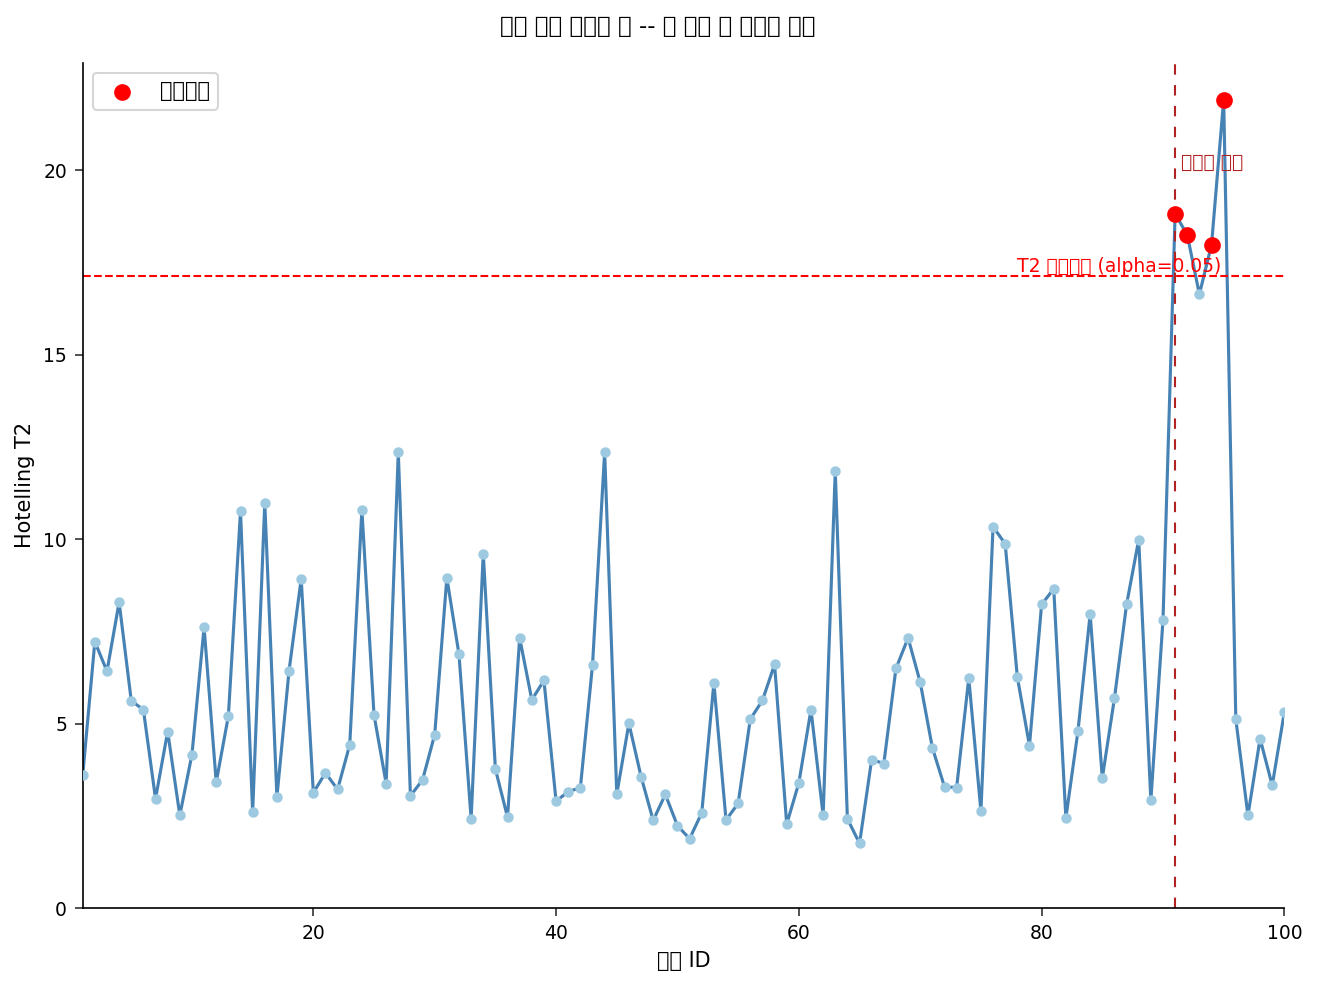

In [4]:
처리 SGPLOT 데이터=mill_scores;
  SERIES  x=coil_id y=_TSQUARED /
          LINEATTRS=(color=steelblue thickness=1.5);
  SCATTER x=coil_id y=_TSQUARED /
          MARKERATTRS=(SYMBOL=circlefilled size=4 color=cx9ecae1);
  SCATTER x=coil_id y=t2_alarm /
          MARKERATTRS=(SYMBOL=circlefilled size=7 color=red)
          legendlabel='관리이탈';
  REFLINE _LIMIT / AXIS=y
          라벨='T2 관리상한 (alpha=0.05)'
          LINEATTRS=(color=red pattern=dash);
  REFLINE 91 / AXIS=x 라벨='채터링 돌발'
          LINEATTRS=(color=firebrick pattern=shortdash);
  XAXIS 라벨='코일 ID' MIN=1 MAX=100;
  YAXIS 라벨='Hotelling T2' MIN=0;
  제목 '열간 압연 스트립 밀 -- 롤 마모 및 채터링 감지';
실행;


---

### 4단계 &mdash; 관리이탈 코일 정량화

관리이탈 코일은 품질 부서를 위한 별도 데이터셋으로 분리된다. `PROC MEANS`는 표시된 코일들의 *T*&sup2; 수준을 관리상태 모집단과 대비하며, 표시된 코일은 이후 스크랩/재작업 라우팅을 위해 내보내진다.

In [5]:
데이터 mill_ooc;
  설정 mill_scores;
  만약 _SIGNAL = 1;
실행;

처리 평균 데이터=mill_scores n mean MAX maxdec=2;
  분류 _SIGNAL;
  변수 _TSQUARED;
  라벨 _SIGNAL='관리 신호' _TSQUARED='T2';
  제목 '관리 상태별 T2 (0 = 관리상태, 1 = 신호)';
실행;

처리 인쇄 데이터=mill_ooc noobs;
  변수 coil_id _TSQUARED _LIMIT;
  라벨 coil_id='코일 ID' _TSQUARED='T2' _LIMIT='관리한계';
  제목 '점검 대상으로 표시된 관리이탈 코일';
실행;

처리 EXPORT 데이터=mill_ooc
            OUTFILE='steel_mill_ooc_coils.csv'
            DBMS=csv REPLACE;
실행;


                                              관리 상태별 T2 (0 = 관리상태, 1 = 신호)                                              

                                                  The MEANS Procedure

                                            Analysis Variable : _TSQUARED T2

        관리 신호                  N Obs           Mean        Maximum
        ----------------------------------------------------------
        0                         96           5.39          16.64
        1                          4          19.24          21.91
        ----------------------------------------------------------

                                                  점검 대상으로 표시된 관리이탈 코일                                                   

    코일 ID         T2          관리한계
       91  18.813814     17.133408
       92  18.249361     17.133408
       94  17.981792     17.133408
       95  21.912329     17.133408




NOTE: DATA mill_ooc


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_ooc (4 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=mill_ooc

NOTE: PROC PRINT completed: 4 observations printed, 3 variables
NOTE: PROC EXPORT data=mill_ooc outfile=steel_mill_ooc_coils.csv

NOTE: Exported 4 rows to steel_mill_ooc_coils.csv.


## 결론

- **모니터링된 코일**: 100개; **관리한계** *T*&sup2; = **17.13**
  (&alpha; = 0.05).
- **관리이탈 코일**: **4개** &mdash; 코일 **91, 92, 94, 95**로 모두
  주입된 채터링 구간(91&ndash;95) 내부에 있다. 코일 93은 *T*&sup2; = 16.64로
  정점을 찍지만 한계 바로 아래이다.
- **최고 심각도**: 코일 95에서 *T*&sup2; = **21.91** (한계의 약 1.3&times;);
  관리상태 코일의 평균 *T*&sup2; &asymp; **5.4**.
- **마모 대 결함**: 점진적인 롤 마모 램프는 후반 코일의 기준선을
  끌어올리지만 그 자체로는 한계를 넘지 않으므로, 단일 다변량 차트가
  완만한 드리프트(관찰 대상)와 급성 채터링 사건(조치 대상)을 구분해 낸다.
- **조치**: 표시된 4개 코일은 점검 및 스크랩/재작업 라우팅을 위해
  `steel_mill_ooc_coils.csv`로 내보내지며, 채터링 시그니처는 다음 캠페인
  전에 점검해야 할 백업롤 베어링을 가리킨다.

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 기밀
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
제공: <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>